# pi0.5-DROID vs Base PaliGemma Activations

Compare matched VLM-prefix activations from `pi05_droid` against the original pretrained PaliGemma backbone (`google/paligemma-3b-pt-224`) on frames from the small real DROID subset described in `examples/droid/README_train.md`.

This notebook captures only shared VLM components: SigLIP vision tower layers, multimodal projector output, and Gemma language-model hidden states for the image/text prefix. It does not inspect the pi0.5 action expert.

## Setup Notes

Small DROID subset from `examples/droid/README_train.md`:

```bash
gsutil -m cp -r gs://gresearch/robotics/droid_raw/1.0.1/IRIS/success/2023-12-04 /path/to/droid_subset
gsutil -m cp -r gs://gresearch/robotics/droid_raw/1.0.1/aggregated-annotations-030724.json /path/to/droid_subset
```

If `pi05_droid` is available only as a JAX checkpoint, convert it once to a PyTorch `model.safetensors` checkpoint:

```bash
uv run examples/convert_jax_model_to_pytorch.py \
  --checkpoint_dir /home/$USER/.cache/openpi/openpi-assets/checkpoints/pi05_droid \
  --output_path /home/$USER/.cache/openpi/openpi-assets/checkpoints/pi05_droid_pytorch
```

The baseline PaliGemma download may require Hugging Face access approval and a local HF token.

In [1]:
!pip install matplotlib

In [2]:
from __future__ import annotations

import contextlib
import json
import math
import os
from pathlib import Path
import sys
import types
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from IPython.display import display
from PIL import Image
import safetensors.torch
from transformers import PaliGemmaForConditionalGeneration

from openpi.models import model as _model
from openpi.models import pi0_config
from openpi.models import tokenizer as _tokenizer
from openpi.models_pytorch import pi0_pytorch
from openpi.models_pytorch import preprocessing_pytorch
from openpi.policies import droid_policy
from openpi.shared import download
from openpi.training import checkpoints as _checkpoints
from openpi.training import config as _config
from openpi import transforms as _transforms
import random

In [3]:
REPO_ROOT = Path("/fs/nexus-scratch/mrislam/openpi")
if str(REPO_ROOT) not in sys.path:
  sys.path.insert(0, str(REPO_ROOT))

In [4]:
# Edit these paths for your machine.
REPO_ROOT = Path("/fs/nexus-scratch/mrislam/openpi")
DROID_SUBSET_DIR = Path(os.environ.get("DROID_SUBSET_DIR", REPO_ROOT / "data/droid_subset"))
PI05_DROID_GS = "gs://openpi-assets/checkpoints/pi05_droid"
PI05_DROID_JAX_DIR = Path(os.environ.get("PI05_DROID_JAX_DIR", REPO_ROOT / "models/pi05_droid")).expanduser()
PI05_DROID_TORCH_DIR = Path(os.environ.get("PI05_DROID_TORCH_DIR", REPO_ROOT / "models/pi05_droid_pytorch")).expanduser()
BASE_PALIGEMMA_ID = "google/paligemma-3b-pt-224"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.bfloat16 if DEVICE.type == "cuda" else torch.float32
MAX_EXAMPLES = 1
VISION_LAYERS = [0, 6, 13, 20, 26]
LANGUAGE_LAYERS = [0, 4, 8, 12, 17]
SAVE_RAW_TENSORS = False
OUTPUT_DIR = Path("outputs/activation_compare/pi05_droid_vs_paligemma")

print(f"device={DEVICE}, dtype={DTYPE}")

device=cuda, dtype=torch.bfloat16


## Data Helpers

Loaded 1 example(s)
prompt: Put the blue sponge in the pot


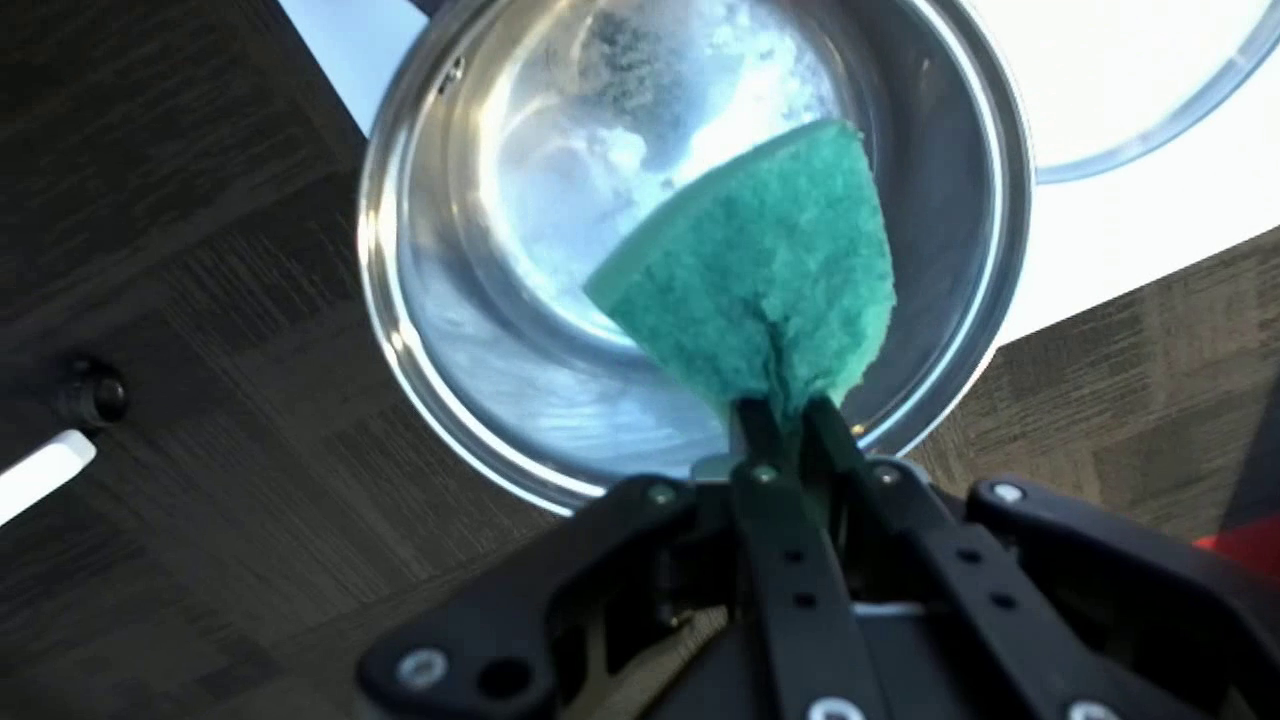

In [5]:
def _episode_id_from_path(episode_path: Path) -> str | None:
    metadata_files = list(episode_path.parent.glob("metadata_*.json"))
    if not metadata_files:
        return None
    return metadata_files[0].stem.split("_")[-1]


def _load_language_annotations(data_dir: Path) -> dict:
    annotation_path = data_dir / "aggregated-annotations-030724.json"
    if not annotation_path.exists():
        return {}
    with annotation_path.open() as f:
        return json.load(f)


def load_droid_raw_examples(data_dir: Path, max_examples: int = 1) -> list[dict]:
    """Load a few real frames from the 30-demo raw DROID subset.

    The helper reuses the parser from examples/droid/convert_droid_data_to_lerobot.py so the camera selection matches
    the README conversion recipe.
    """
    if not data_dir.exists():
        raise FileNotFoundError(
            f"DROID_SUBSET_DIR does not exist: {data_dir}. Download the 30-demo subset shown above or set DROID_SUBSET_DIR."
        )

    try:
        from examples.droid.convert_droid_data_to_lerobot import load_trajectory
    except ModuleNotFoundError as exc:
        if exc.name != "lerobot":
            raise
        # The raw trajectory parser lives in the conversion script, whose top-level LeRobot imports are only needed
        # when writing a converted dataset. Stub them so this notebook can read raw DROID frames without installing
        # the optional LeRobot stack.
        lerobot = types.ModuleType("lerobot")
        common = types.ModuleType("lerobot.common")
        datasets = types.ModuleType("lerobot.common.datasets")
        lerobot_dataset = types.ModuleType("lerobot.common.datasets.lerobot_dataset")
        lerobot_dataset.HF_LEROBOT_HOME = Path("~/.cache/huggingface/lerobot").expanduser()
        lerobot_dataset.LeRobotDataset = object
        sys.modules.update(
            {
                "lerobot": lerobot,
                "lerobot.common": common,
                "lerobot.common.datasets": datasets,
                "lerobot.common.datasets.lerobot_dataset": lerobot_dataset,
            }
        )
        from examples.droid.convert_droid_data_to_lerobot import load_trajectory

    annotations = _load_language_annotations(data_dir)
    episode_paths = sorted(data_dir.glob("**/trajectory.h5"))
    if not episode_paths:
        raise FileNotFoundError(f"No trajectory.h5 files found under {data_dir}")

    examples = []
    random_episodes = random.sample(episode_paths, max_examples)
    for episode_path in random_episodes:
        recording_dir = episode_path.parent / "recordings" / "MP4"
        trajectory = load_trajectory(str(episode_path), recording_folderpath=str(recording_dir), num_samples_per_traj=1)
        if len(trajectory) == 0:
            continue
        step = trajectory[0]
        camera_types = step["observation"]["camera_type"]
        wrist_ids = [k for k, v in camera_types.items() if v == 0]
        exterior_ids = [k for k, v in camera_types.items() if v != 0]
        if not wrist_ids or not exterior_ids:
            warnings.warn(f"Skipping {episode_path}: missing wrist or exterior camera")
            continue

        episode_id = _episode_id_from_path(episode_path)
        prompt = annotations.get(episode_id or "", {}).get("language_instruction1", "Do something")

        examples.append(
            {
                "observation/exterior_image_1_left": step["observation"]["image"][exterior_ids[0]][..., ::-1].copy(),
                "observation/wrist_image_left": step["observation"]["image"][wrist_ids[0]][..., ::-1].copy(),
                "observation/joint_position": np.asarray(step["observation"]["robot_state"]["joint_positions"], dtype=np.float32),
                "observation/gripper_position": np.asarray([step["observation"]["robot_state"]["gripper_position"]], dtype=np.float32),
                "prompt": prompt,
                "episode_path": str(episode_path),
            }
        )
    if not examples:
        raise RuntimeError(f"Found trajectories under {data_dir}, but could not load any usable frames")
    return examples


def load_examples_or_dummy(data_dir: Path, max_examples: int = 1) -> list[dict]:
    try:
        return load_droid_raw_examples(data_dir, max_examples=max_examples)
    except Exception as exc:
        warnings.warn(f"Falling back to droid_policy.make_droid_example() for smoke testing: {exc}")
        return [droid_policy.make_droid_example() for _ in range(max_examples)]


examples = load_examples_or_dummy(DROID_SUBSET_DIR, MAX_EXAMPLES)
print(f"Loaded {len(examples)} example(s)")
print("prompt:", examples[0]["prompt"])
display(Image.fromarray(np.asarray(examples[0]["observation/wrist_image_left"], dtype=np.uint8)))

## Model Loading

In [6]:
def ensure_pi05_torch_checkpoint(torch_dir: Path) -> Path:
    safetensors_path = torch_dir / "model.safetensors"
    if safetensors_path.exists():
        return safetensors_path

    local_jax_dir = PI05_DROID_JAX_DIR if PI05_DROID_JAX_DIR.exists() else download.maybe_download(PI05_DROID_GS)
    raise FileNotFoundError(
        "Could not find a converted pi05_droid PyTorch checkpoint at "
        f"{safetensors_path}. Convert the JAX checkpoint with:\n"
        f"uv run examples/convert_jax_model_to_pytorch.py --checkpoint_dir {local_jax_dir} --output_path {torch_dir}"
    )


def load_pi05_vlm(torch_dir: Path):
    # Use the same pi05_droid TrainConfig that policy_config.create_trained_policy uses for inference.
    config = _config.get_config("pi05_droid")
    model = pi0_pytorch.PI0Pytorch(config.model)
    safetensors.torch.load_model(model, str(ensure_pi05_torch_checkpoint(torch_dir)), strict=False)
    model.eval().to(DEVICE)
    return config, model, model.paligemma_with_expert.paligemma


def load_base_paligemma():
    model = PaliGemmaForConditionalGeneration.from_pretrained(
        BASE_PALIGEMMA_ID,
        torch_dtype=DTYPE,
        low_cpu_mem_usage=True,
    )
    model.eval().to(DEVICE)
    return model


pi_config, pi05_model, pi05_vlm = load_pi05_vlm(PI05_DROID_TORCH_DIR)
base_vlm = load_base_paligemma()
print("pi05 VLM:", type(pi05_vlm).__name__)
print("base VLM:", type(base_vlm).__name__)

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

pi05 VLM: PaliGemmaForConditionalGeneration
base VLM: PaliGemmaForConditionalGeneration


In [7]:
IMAGE_STREAMS = ("base_0_rgb", "left_wrist_0_rgb", "right_wrist_0_rgb")
IMAGE_STREAM_LABELS = {
    "base_0_rgb": "external camera",
    "left_wrist_0_rgb": "left wrist camera",
    "right_wrist_0_rgb": "right wrist placeholder",
}


def resolve_pi05_checkpoint_dir() -> Path:
    if PI05_DROID_TORCH_DIR.exists():
        return PI05_DROID_TORCH_DIR
    if PI05_DROID_JAX_DIR.exists():
        return PI05_DROID_JAX_DIR
    return Path(download.maybe_download(PI05_DROID_GS))


def load_pi05_norm_stats() -> dict:
    checkpoint_dir = resolve_pi05_checkpoint_dir()
    assets_dir = checkpoint_dir / "assets"
    if not assets_dir.exists() and PI05_DROID_JAX_DIR.exists():
        assets_dir = PI05_DROID_JAX_DIR / "assets"
    if not assets_dir.exists():
        downloaded_dir = Path(download.maybe_download(PI05_DROID_GS))
        assets_dir = downloaded_dir / "assets"
    return _checkpoints.load_norm_stats(assets_dir, "droid")


def torch_batch_tree(data):
    if isinstance(data, dict):
        return {key: torch_batch_tree(value) for key, value in data.items()}
    return torch.from_numpy(np.asarray(data)).to(DEVICE)[None, ...]


def prepare_pi05_prefix_inputs(example: dict, config) -> dict:
    data_config = config.data.create(config.assets_dirs, config.model)
    input_transform = _transforms.compose(
        [
            _transforms.InjectDefaultPrompt(None),
            *data_config.data_transforms.inputs,
            _transforms.Normalize(PI05_NORM_STATS, use_quantiles=data_config.use_quantile_norm),
            *data_config.model_transforms.inputs,
        ]
    )
    transformed = input_transform(dict(example))
    torch_inputs = torch_batch_tree(transformed)
    observation = _model.Observation.from_dict(torch_inputs)
    return {
        "observation": observation,
        "images": observation.images,
        "image_masks": observation.image_masks,
        "pixel_values": observation.images["base_0_rgb"],
        "input_ids": observation.tokenized_prompt,
        "attention_mask": observation.tokenized_prompt_mask,
    }

PI05_NORM_STATS = load_pi05_norm_stats()
prefix_inputs = [prepare_pi05_prefix_inputs(example, pi_config) for example in examples]
for key, value in prefix_inputs[0].items():
    if isinstance(value, torch.Tensor):
        print(key, tuple(value.shape), value.dtype, value.device)
for key in IMAGE_STREAMS:
    image = prefix_inputs[0]["images"][key]
    mask = prefix_inputs[0]["image_masks"][key]
    print(f"image[{key}]", tuple(image.shape), image.dtype, image.device, "mask=", mask.detach().cpu().tolist())


pixel_values (1, 3, 224, 224) torch.float32 cuda:0
input_ids (1, 200) torch.int64 cuda:0
attention_mask (1, 200) torch.bool cuda:0
image[base_0_rgb] (1, 3, 224, 224) torch.float32 cuda:0 mask= [True]
image[left_wrist_0_rgb] (1, 3, 224, 224) torch.float32 cuda:0 mask= [True]
image[right_wrist_0_rgb] (1, 3, 224, 224) torch.float32 cuda:0 mask= [False]


## Activation Capture

In [8]:
def get_module_by_path(root: torch.nn.Module, path: str) -> torch.nn.Module:
    module = root
    for part in path.split("."):
        module = module[int(part)] if part.isdigit() else getattr(module, part)
    return module


def detach_output(output):
    if isinstance(output, torch.Tensor):
        return output.detach().float().cpu()
    if hasattr(output, "last_hidden_state"):
        return output.last_hidden_state.detach().float().cpu()
    if isinstance(output, (tuple, list)):
        for item in output:
            if isinstance(item, torch.Tensor):
                return item.detach().float().cpu()
            if hasattr(item, "last_hidden_state"):
                return item.last_hidden_state.detach().float().cpu()
    raise TypeError(f"Unsupported hook output type: {type(output)}")


@contextlib.contextmanager
def capture_modules(model: torch.nn.Module, module_paths: dict[str, str]):
    activations = {}
    activation_chunks = {}
    handles = []
    for name, path in module_paths.items():
        try:
            module = get_module_by_path(model, path)
        except Exception as exc:
            warnings.warn(f"Skipping missing module {name} at {path}: {exc}")
            continue

        def hook(_module, _inputs, output, *, name=name):
            activation_chunks.setdefault(name, []).append(detach_output(output))

        handles.append(module.register_forward_hook(hook))
    try:
        yield activations
    finally:
        for name, chunks in activation_chunks.items():
            activations[name] = torch.cat(chunks, dim=1) if len(chunks) > 1 and chunks[0].ndim >= 3 else chunks[-1]
        for handle in handles:
            handle.remove()


def build_hook_paths(vision_layers: list[int], language_layers: list[int]) -> dict[str, str]:
    paths = {"projector": "model.multi_modal_projector"}
    for layer in vision_layers:
        paths[f"vision.{layer:02d}"] = f"model.vision_tower.vision_model.encoder.layers.{layer}"
    for layer in language_layers:
        paths[f"language.{layer:02d}"] = f"model.language_model.layers.{layer}"
    return paths


HOOK_PATHS = build_hook_paths(VISION_LAYERS, LANGUAGE_LAYERS)
HOOK_PATHS

{'projector': 'model.multi_modal_projector',
 'vision.00': 'model.vision_tower.vision_model.encoder.layers.0',
 'vision.06': 'model.vision_tower.vision_model.encoder.layers.6',
 'vision.13': 'model.vision_tower.vision_model.encoder.layers.13',
 'vision.20': 'model.vision_tower.vision_model.encoder.layers.20',
 'vision.26': 'model.vision_tower.vision_model.encoder.layers.26',
 'language.00': 'model.language_model.layers.0',
 'language.04': 'model.language_model.layers.4',
 'language.08': 'model.language_model.layers.8',
 'language.12': 'model.language_model.layers.12',
 'language.17': 'model.language_model.layers.17'}

In [9]:
def pi05_prefix_components(inputs: dict):
    images, img_masks, lang_tokens, lang_masks, _state = pi05_model._preprocess_observation(
        inputs["observation"], train=False
    )
    return images, img_masks, lang_tokens, lang_masks


@torch.no_grad()
def run_pi05_author_prefix(inputs: dict):
    images, img_masks, lang_tokens, lang_masks = pi05_prefix_components(inputs)
    prefix_embs, prefix_pad_masks, prefix_att_masks = pi05_model.embed_prefix(
        images, img_masks, lang_tokens, lang_masks
    )
    prefix_att_2d_masks = pi0_pytorch.make_att_2d_masks(prefix_pad_masks, prefix_att_masks)
    prefix_position_ids = torch.cumsum(prefix_pad_masks, dim=1) - 1
    prefix_att_2d_masks_4d = pi05_model._prepare_attention_masks_4d(prefix_att_2d_masks)
    pi05_model.paligemma_with_expert.paligemma.language_model.config._attn_implementation = "eager"

    return pi05_model.paligemma_with_expert.forward(
        attention_mask=prefix_att_2d_masks_4d,
        position_ids=prefix_position_ids,
        past_key_values=None,
        inputs_embeds=[prefix_embs, None],
        use_cache=True,
    )


@torch.no_grad()
def run_base_multiview_prefix(inputs: dict):
    images, img_masks, lang_tokens, lang_masks = pi05_prefix_components(inputs)
    image_embeds = []
    pad_masks = []
    att_masks = []

    for image, image_mask in zip(images, img_masks, strict=True):
        image_features = base_vlm.model.get_image_features(image)
        image_embeds.append(image_features)
        batch_size, num_image_tokens = image_features.shape[:2]
        pad_masks.append(image_mask[:, None].expand(batch_size, num_image_tokens))
        att_masks += [0] * num_image_tokens

    text_embeds = base_vlm.language_model.embed_tokens(lang_tokens)
    text_embeds = text_embeds * math.sqrt(text_embeds.shape[-1])
    if text_embeds.dtype != image_embeds[0].dtype:
        text_embeds = text_embeds.to(image_embeds[0].dtype)

    inputs_embeds = torch.cat([*image_embeds, text_embeds], dim=1)
    pad_masks.append(lang_masks)
    att_masks += [0] * text_embeds.shape[1]
    prefix_pad_masks = torch.cat(pad_masks, dim=1)
    prefix_att_masks = torch.tensor(att_masks, dtype=torch.bool, device=prefix_pad_masks.device)[None, :].expand(
        prefix_pad_masks.shape[0], len(att_masks)
    )
    prefix_att_2d_masks = pi0_pytorch.make_att_2d_masks(prefix_pad_masks, prefix_att_masks)
    prefix_position_ids = torch.cumsum(prefix_pad_masks, dim=1) - 1
    prefix_att_2d_masks_4d = pi05_model._prepare_attention_masks_4d(prefix_att_2d_masks)
    base_vlm.language_model.config._attn_implementation = "eager"

    return base_vlm.language_model(
        inputs_embeds=inputs_embeds,
        attention_mask=prefix_att_2d_masks_4d,
        position_ids=prefix_position_ids,
        use_cache=False,
    )


def capture_model_activations(model_to_hook, run_fn, inputs: dict) -> dict[str, torch.Tensor]:
    with capture_modules(model_to_hook, HOOK_PATHS) as acts:
        _ = run_fn(inputs)
    return dict(acts)


pi05_acts = []
base_acts = []
for inputs in prefix_inputs:
    pi05_acts.append(capture_model_activations(pi05_vlm, run_pi05_author_prefix, inputs))
    base_acts.append(capture_model_activations(base_vlm, run_base_multiview_prefix, inputs))

print("pi05 captured:", sorted(pi05_acts[0]))
print("base captured:", sorted(base_acts[0]))
for name in sorted(set(pi05_acts[0]) & set(base_acts[0])):
    print(name, tuple(pi05_acts[0][name].shape), tuple(base_acts[0][name].shape))

pi05 captured: ['language.00', 'language.04', 'language.08', 'language.12', 'language.17', 'projector', 'vision.00', 'vision.06', 'vision.13', 'vision.20', 'vision.26']
base captured: ['language.00', 'language.04', 'language.08', 'language.12', 'language.17', 'projector', 'vision.00', 'vision.06', 'vision.13', 'vision.20', 'vision.26']
language.00 (1, 968, 2048) (1, 968, 2048)
language.04 (1, 968, 2048) (1, 968, 2048)
language.08 (1, 968, 2048) (1, 968, 2048)
language.12 (1, 968, 2048) (1, 968, 2048)
language.17 (1, 968, 2048) (1, 968, 2048)
projector (1, 768, 2048) (1, 768, 2048)
vision.00 (1, 768, 1152) (1, 768, 1152)
vision.06 (1, 768, 1152) (1, 768, 1152)
vision.13 (1, 768, 1152) (1, 768, 1152)
vision.20 (1, 768, 1152) (1, 768, 1152)
vision.26 (1, 768, 1152) (1, 768, 1152)


## Metrics

## How To Read The Metrics

Each row compares one captured activation tensor from `pi05_droid` (`*_a` columns) with the matching tensor from base PaliGemma (`*_b` columns). Lower-level vision layers often remain more similar; later language layers can diverge more because DROID fine-tuning changes how the shared VLM represents the robot-conditioned prompt.

Key columns:

- `cosine`: direction similarity after flattening the activation. `1.0` means nearly identical direction; lower values indicate representational drift.
- `norm_l2`: L2 difference normalized by average activation norm. `0.0` means identical; larger values mean larger magnitude changes.
- `mean_a/std_a` and `mean_b/std_b`: activation distribution shifts. Large std changes can indicate scale changes even when cosine remains high.
- `token_norm_*`: average per-token or per-patch vector norms. These help identify whether specific image patches or prefix tokens became unusually strong or weak.

The plots below are exploratory diagnostics, not pass/fail tests. Use them to find layers where fine-tuning changed the VLM most, then inspect those layers with the selector.


In [10]:
def flatten_for_metric(x: torch.Tensor) -> torch.Tensor:
    return x.reshape(x.shape[0], -1) if x.ndim > 1 else x.reshape(1, -1)


def compare_tensors(a: torch.Tensor, b: torch.Tensor, eps: float = 1e-8) -> dict[str, float | tuple[int, ...]]:
    if a.shape != b.shape:
        min_shape = tuple(min(x, y) for x, y in zip(a.shape, b.shape, strict=False))
        warnings.warn(f"Shape mismatch {tuple(a.shape)} vs {tuple(b.shape)}; cropping to {min_shape}")
        slices = tuple(slice(0, s) for s in min_shape)
        a = a[slices]
        b = b[slices]

    a = a.float()
    b = b.float()
    af = flatten_for_metric(a)
    bf = flatten_for_metric(b)
    cosine = F.cosine_similarity(af, bf, dim=-1).mean().item()
    l2 = torch.linalg.vector_norm(af - bf, dim=-1).mean().item()
    norm = 0.5 * (torch.linalg.vector_norm(af, dim=-1).mean() + torch.linalg.vector_norm(bf, dim=-1).mean()).item()
    token_norm_a = torch.linalg.vector_norm(a.reshape(-1, a.shape[-1]), dim=-1) if a.ndim >= 2 else a.abs()
    token_norm_b = torch.linalg.vector_norm(b.reshape(-1, b.shape[-1]), dim=-1) if b.ndim >= 2 else b.abs()
    return {
        "shape_a": tuple(a.shape),
        "shape_b": tuple(b.shape),
        "cosine": cosine,
        "norm_l2": l2 / (norm + eps),
        "mean_a": a.mean().item(),
        "std_a": a.std().item(),
        "mean_b": b.mean().item(),
        "std_b": b.std().item(),
        "token_norm_mean_a": token_norm_a.mean().item(),
        "token_norm_mean_b": token_norm_b.mean().item(),
        "token_norm_std_a": token_norm_a.std().item(),
        "token_norm_std_b": token_norm_b.std().item(),
    }


def smoke_test_metrics():
    x = torch.randn(2, 4, 8)
    same = compare_tensors(x, x.clone())
    shifted = compare_tensors(x, x + 0.1)
    assert same["cosine"] > 0.999
    assert same["norm_l2"] < 1e-6
    assert shifted["norm_l2"] > same["norm_l2"]
    return same, shifted


same_metrics, shifted_metrics = smoke_test_metrics()
print("synthetic identical:", same_metrics)
print("synthetic shifted:", shifted_metrics)

synthetic identical: {'shape_a': (2, 4, 8), 'shape_b': (2, 4, 8), 'cosine': 0.9999999403953552, 'norm_l2': 0.0, 'mean_a': 0.05633123964071274, 'std_a': 0.8824092745780945, 'mean_b': 0.05633123964071274, 'std_b': 0.8824092745780945, 'token_norm_mean_a': 2.4251978397369385, 'token_norm_mean_b': 2.4251978397369385, 'token_norm_std_a': 0.5612640380859375, 'token_norm_std_b': 0.5612640380859375}
synthetic shifted: {'shape_a': (2, 4, 8), 'shape_b': (2, 4, 8), 'cosine': 0.9936944246292114, 'norm_l2': 0.11327732441857867, 'mean_a': 0.05633123964071274, 'std_a': 0.8824092745780945, 'mean_b': 0.15633124113082886, 'std_b': 0.8824092745780945, 'token_norm_mean_a': 2.4251978397369385, 'token_norm_mean_b': 2.449869155883789, 'token_norm_std_a': 0.5612640380859375, 'token_norm_std_b': 0.6099138259887695}


In [11]:
rows = []
for example_idx, (left, right) in enumerate(zip(pi05_acts, base_acts, strict=True)):
    for name in sorted(set(left) & set(right)):
        metrics = compare_tensors(left[name], right[name])
        rows.append({"example": example_idx, "layer": name, **metrics})

metrics_df = pd.DataFrame(rows)
display(metrics_df)
display(metrics_df.groupby("layer")[["cosine", "norm_l2", "mean_a", "std_a", "mean_b", "std_b"]].mean())

,example,layer,shape_a,shape_b,cosine,norm_l2,mean_a,std_a,mean_b,std_b,token_norm_mean_a,token_norm_mean_b,token_norm_std_a,token_norm_std_b
0,0,language.00,"(1, 968, 2048)","(1, 968, 2048)",0.908457,1.065548,-0.263170,13.693053,-0.114967,4.572160,604.948059,204.149460,134.898438,34.117172
1,0,language.04,"(1, 968, 2048)","(1, 968, 2048)",0.832283,1.527206,-0.448283,23.058882,-0.048309,3.475307,925.141602,155.661438,483.437561,22.584412
2,0,language.08,"(1, 968, 2048)","(1, 968, 2048)",0.752175,1.528426,-0.439762,25.616182,-0.020787,4.090652,1024.397217,162.241684,543.309937,89.200829
3,0,language.12,"(1, 968, 2048)","(1, 968, 2048)",0.754717,1.541458,-0.279318,28.794907,-0.009861,4.437543,1255.667725,177.144424,348.819702,94.647133
4,0,language.17,"(1, 968, 2048)","(1, 968, 2048)",0.131777,1.976466,8.151347,1079.286865,0.599410,11.375428,15380.644531,504.027557,46383.464844,108.239731
5,0,projector,"(1, 768, 2048)","(1, 768, 2048)",0.408805,1.547621,-0.078220,5.166317,0.011945,1.072897,232.697922,47.988415,22.971647,7.412271
6,0,vision.00,"(1, 768, 1152)","(1, 768, 1152)",0.834200,0.635650,-0.755223,1.682346,-0.804690,1.132282,58.461788,41.715221,22.370001,21.985292
7,0,vision.06,"(1, 768, 1152)","(1, 768, 1152)",0.381399,1.236536,0.136607,2.313285,-0.723840,0.932521,76.460953,35.452702,18.448252,18.679287
8,0,vision.13,"(1, 768, 1152)","(1, 768, 1152)",0.171224,1.547965,0.565063,4.408389,-0.796923,0.960152,148.850494,37.938831,24.494017,18.834698
9,0,vision.20,"(1, 768, 1152)","(1, 768, 1152)",0.194442,1.681334,1.186342,10.205041,-0.867848,1.483068,344.760956,55.148792,52.318481,18.987570


,cosine,norm_l2,mean_a,std_a,mean_b,std_b
layer,,,,,,
language.00,0.908457,1.065548,-0.263170,13.693053,-0.114967,4.572160
language.04,0.832283,1.527206,-0.448283,23.058882,-0.048309,3.475307
language.08,0.752175,1.528426,-0.439762,25.616182,-0.020787,4.090652
language.12,0.754717,1.541458,-0.279318,28.794907,-0.009861,4.437543
language.17,0.131777,1.976466,8.151347,1079.286865,0.599410,11.375428
projector,0.408805,1.547621,-0.078220,5.166317,0.011945,1.072897
vision.00,0.834200,0.635650,-0.755223,1.682346,-0.804690,1.132282
vision.06,0.381399,1.236536,0.136607,2.313285,-0.723840,0.932521
vision.13,0.171224,1.547965,0.565063,4.408389,-0.796923,0.960152


## Interactive Views

The first plot summarizes drift across all captured layers. The selector then shows one layer at a time:

- The line plot compares per-token or per-patch activation norms for the two models.
- The heatmap and overlay show the selected 16x16 image-patch block. The prefix order is `base_0_rgb` patches, `left_wrist_0_rgb` patches, masked `right_wrist_0_rgb` placeholder patches, then text/state prompt tokens.
- The 1D strip shows all token differences in sequence order, including all image streams and text prefix tokens.


## Interactive Views

,example,layer,cosine,norm_l2,mean_a,std_a,mean_b,std_b,token_norm_mean_a,token_norm_mean_b
6,0,vision.00,0.834200,0.635650,-0.755223,1.682346,-0.804690,1.132282,58.461788,41.715221
7,0,vision.06,0.381399,1.236536,0.136607,2.313285,-0.723840,0.932521,76.460953,35.452702
8,0,vision.13,0.171224,1.547965,0.565063,4.408389,-0.796923,0.960152,148.850494,37.938831
9,0,vision.20,0.194442,1.681334,1.186342,10.205041,-0.867848,1.483068,344.760956,55.148792
10,0,vision.26,0.357526,1.663822,1.733448,19.568502,-0.819682,2.829865,653.946228,94.686310
5,0,projector,0.408805,1.547621,-0.078220,5.166317,0.011945,1.072897,232.697922,47.988415
0,0,language.00,0.908457,1.065548,-0.263170,13.693053,-0.114967,4.572160,604.948059,204.149460
1,0,language.04,0.832283,1.527206,-0.448283,23.058882,-0.048309,3.475307,925.141602,155.661438
2,0,language.08,0.752175,1.528426,-0.439762,25.616182,-0.020787,4.090652,1024.397217,162.241684
3,0,language.12,0.754717,1.541458,-0.279318,28.794907,-0.009861,4.437543,1255.667725,177.144424


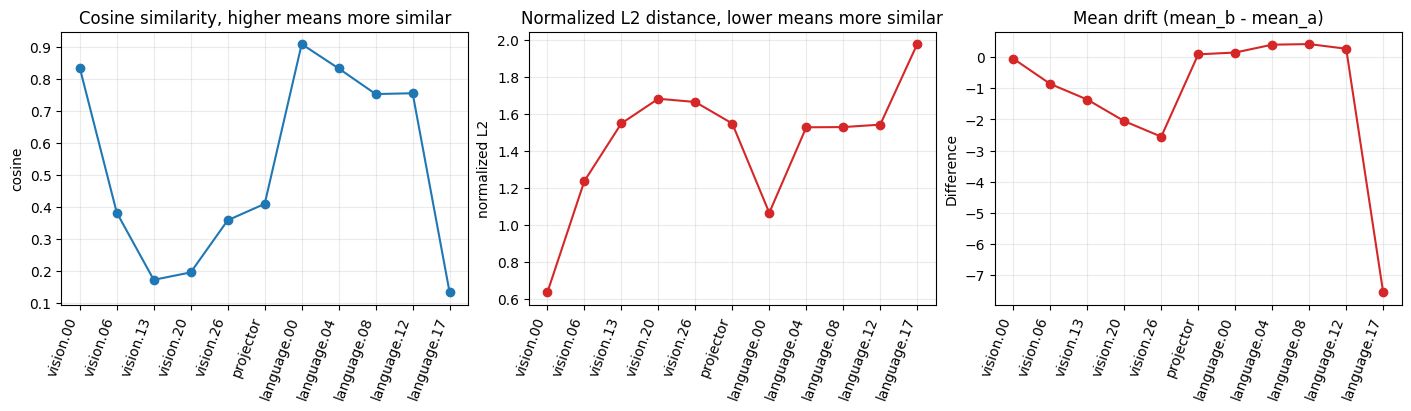

In [12]:
try:
    import ipywidgets as widgets
except ImportError:
    widgets = None


def layer_sort_key(layer: str):
    group_order = {"vision": 0, "projector": 1, "language": 2}
    group = layer.split(".")[0]
    number = int(layer.split(".")[1]) if "." in layer and layer.split(".")[1].isdigit() else -1
    return group_order.get(group, 99), number, layer


def plot_metric_summary(df: pd.DataFrame):
    ordered = df.sort_values("layer", key=lambda s: s.map(layer_sort_key))
    x = np.arange(len(ordered))
    labels = ordered["layer"].tolist()

    fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
    axes[0].plot(x, ordered["cosine"], marker="o")
    axes[0].set_title("Cosine similarity, higher means more similar")
    axes[0].set_ylabel("cosine")
    axes[0].set_xticks(x, labels, rotation=70, ha="right")
    axes[0].grid(alpha=0.25)

    axes[1].plot(x, ordered["norm_l2"], marker="o", color="tab:red")
    axes[1].set_title("Normalized L2 distance, lower means more similar")
    axes[1].set_ylabel("normalized L2")
    axes[1].set_xticks(x, labels, rotation=70, ha="right")
    axes[1].grid(alpha=0.25)

    axes[2].plot(x, ordered["mean_b"] - ordered["mean_a"], marker="o", color="tab:red")
    axes[2].set_title("Mean drift (mean_b - mean_a)")
    axes[2].set_ylabel("Difference")
    axes[2].set_xticks(x, labels, rotation=70, ha="right")
    axes[2].grid(alpha=0.25)
    plt.show()


summary_cols = ["example", "layer", "cosine", "norm_l2", "mean_a", "std_a", "mean_b", "std_b", "token_norm_mean_a", "token_norm_mean_b"]
display(metrics_df[summary_cols].sort_values("layer", key=lambda s: s.map(layer_sort_key)))
plot_metric_summary(metrics_df)


In [13]:
prefix_inputs

[{'observation': Observation(images={'base_0_rgb': tensor([[[[-1., -1., -1.,  ..., -1., -1., -1.],
            [-1., -1., -1.,  ..., -1., -1., -1.],
            [-1., -1., -1.,  ..., -1., -1., -1.],
            ...,
            [-1., -1., -1.,  ..., -1., -1., -1.],
            [-1., -1., -1.,  ..., -1., -1., -1.],
            [-1., -1., -1.,  ..., -1., -1., -1.]],
  
           [[-1., -1., -1.,  ..., -1., -1., -1.],
            [-1., -1., -1.,  ..., -1., -1., -1.],
            [-1., -1., -1.,  ..., -1., -1., -1.],
            ...,
            [-1., -1., -1.,  ..., -1., -1., -1.],
            [-1., -1., -1.,  ..., -1., -1., -1.],
            [-1., -1., -1.,  ..., -1., -1., -1.]],
  
           [[-1., -1., -1.,  ..., -1., -1., -1.],
            [-1., -1., -1.,  ..., -1., -1., -1.],
            [-1., -1., -1.,  ..., -1., -1., -1.],
            ...,
            [-1., -1., -1.,  ..., -1., -1., -1.],
            [-1., -1., -1.,  ..., -1., -1., -1.],
            [-1., -1., -1.,  ..., -1., -1.

In [14]:
def crop_to_common_shape(a: torch.Tensor, b: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    if a.shape == b.shape:
        return a, b
    min_shape = tuple(min(x, y) for x, y in zip(a.shape, b.shape, strict=False))
    slices = tuple(slice(0, s) for s in min_shape)
    return a[slices], b[slices]


def vector_norm_series(x: torch.Tensor) -> np.ndarray:
    # Treat the final dimension as the activation channel dimension for token/patch activations.
    return torch.linalg.vector_norm(x.reshape(-1, x.shape[-1]).float(), dim=-1).cpu().numpy()


def token_differences(a: torch.Tensor, b: torch.Tensor) -> np.ndarray:
    a, b = crop_to_common_shape(a, b)
    diff = (a.float() - b.float()).abs()
    if diff.ndim == 3:  # [batch, tokens, channels]
        return diff.mean(dim=-1).squeeze(0).cpu().numpy()
    if diff.ndim == 4:  # [batch, channels, height, width] or [batch, height, width, channels]
        if diff.shape[1] in (1, 3):
            return diff.mean(dim=1).reshape(-1).cpu().numpy()
        return diff.mean(dim=-1).reshape(-1).cpu().numpy()
    return diff.reshape(-1).cpu().numpy()


def token_cosine_similarities(a: torch.Tensor, b: torch.Tensor) -> np.ndarray:
    a, b = crop_to_common_shape(a, b)
    a = a.float()
    b = b.float()
    if a.ndim == 3:  # [batch, tokens, channels]
        return np.abs(F.cosine_similarity(a, b, dim=-1).squeeze(0).cpu().numpy())
    if a.ndim == 4:  # [batch, channels, height, width] or [batch, height, width, channels]
        if a.shape[1] in (1, 3):
            return np.abs(F.cosine_similarity(a, b, dim=1).reshape(-1).cpu().numpy())
        return np.abs(F.cosine_similarity(a, b, dim=-1).reshape(-1).cpu().numpy())
    return np.abs(F.cosine_similarity(a.reshape(-1, a.shape[-1]), b.reshape(-1, b.shape[-1]), dim=-1).cpu().numpy())


PLOT_SCALE_PERCENTILE = 99.0


def layer_group(layer: str) -> str:
    group = layer.split(".", 1)[0]
    return group if group in {"vision", "projector", "language"} else "other"


def robust_upper_limit(chunks: list[np.ndarray], *, percentile: float) -> float:
    values = [np.asarray(chunk).reshape(-1) for chunk in chunks if np.asarray(chunk).size]
    if not values:
        return 1.0
    values = np.concatenate(values)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return 1.0

    max_value = float(np.max(values))
    if values.size < 2:
        return max_value if max_value > 0 else 1.0

    limit = float(np.percentile(values, percentile))
    if not np.isfinite(limit) or limit <= 0:
        limit = max_value
    return limit if limit > 0 else 1.0


def compute_grouped_plot_limits(
    pi_acts: list[dict[str, torch.Tensor]],
    base_acts: list[dict[str, torch.Tensor]],
    *,
    percentile: float = PLOT_SCALE_PERCENTILE,
):
    """Use fixed robust scales within each layer group for visual comparison."""
    grouped_values = {
        "vision": {"norm": [], "diff": []},
        "projector": {"norm": [], "diff": []},
        "language": {"norm": [], "diff": []},
        "other": {"norm": [], "diff": []},
    }
    for example_idx, (left, right) in enumerate(zip(pi_acts, base_acts, strict=True)):
        for layer in set(left) & set(right):
            a, b = crop_to_common_shape(left[layer], right[layer])
            if a.numel() == 0 or b.numel() == 0:
                continue
            values = grouped_values[layer_group(layer)]
            values["norm"].append(vector_norm_series(a))
            values["norm"].append(vector_norm_series(b))
            diff = token_differences(a, b)
            if diff.size:
                values["diff"].append(diff)

    return {
        group: {
            "norm_ylim": (0.0, robust_upper_limit(values["norm"], percentile=percentile)),
            "diff_clim": (0.0, robust_upper_limit(values["diff"], percentile=percentile)),
            "percentile": percentile,
        }
        for group, values in grouped_values.items()
    }


available_layers = sorted(set(pi05_acts[0]) & set(base_acts[0]), key=layer_sort_key)
GROUPED_PLOT_LIMITS = compute_grouped_plot_limits(pi05_acts, base_acts)
print("Grouped robust plot scales:", GROUPED_PLOT_LIMITS)


IMAGE_TOKEN_COUNT = 256


def image_stream_offset(image_stream: str) -> int:
    return IMAGE_STREAMS.index(image_stream) * IMAGE_TOKEN_COUNT


def model_input_image(example_idx: int, image_stream: str) -> np.ndarray:
    image = prefix_inputs[example_idx]["images"][image_stream].detach().float().cpu().numpy()
    if image.ndim == 4:
        image = image[0]
    if image.shape[0] == 3:
        image = np.moveaxis(image, 0, -1)
    return np.clip((image + 1.0) / 2.0, 0.0, 1.0)


def plot_patch_heatmap(
    values: np.ndarray,
    layer: str,
    *,
    image_stream: str,
    clim: tuple[float, float],
    cmap: str,
    label: str,
    title_metric: str,
):
    # SigLIP at 224 px with 14 px patches gives 16x16 = 256 image tokens per image stream.
    start = image_stream_offset(image_stream)
    end = start + IMAGE_TOKEN_COUNT
    if values.shape[0] >= end:
        patch_values = values[start:end]
        plt.figure(figsize=(4.5, 4))
        plt.imshow(patch_values.reshape(16, 16), cmap=cmap, vmin=clim[0], vmax=clim[1])
        plt.title(f"{IMAGE_STREAM_LABELS[image_stream]} patch {title_metric}: {layer}")
        plt.xlabel("patch x")
        plt.ylabel("patch y")
        plt.colorbar(label=label)
        plt.show()
    else:
        print(f"No {IMAGE_STREAM_LABELS[image_stream]} heatmap for {layer}: only {values.shape[0]} token(s).")


def plot_patch_overlay(
    values: np.ndarray,
    image: np.ndarray,
    layer: str,
    *,
    image_stream: str,
    clim: tuple[float, float],
    cmap: str,
    label: str,
    title_metric: str,
    alpha: float = 0.55,
):
    # Overlay only the selected 16x16 image-patch region. Later language positions are text tokens.
    start = image_stream_offset(image_stream)
    end = start + IMAGE_TOKEN_COUNT
    if values.shape[0] < end:
        print(f"No {IMAGE_STREAM_LABELS[image_stream]} overlay for {layer}: only {values.shape[0]} token(s).")
        return

    patch_values = values[start:end].reshape(16, 16)
    height, width = image.shape[:2]
    plt.figure(figsize=(5.5, 5))
    plt.imshow(image)
    plt.imshow(
        patch_values,
        cmap=cmap,
        vmin=clim[0],
        vmax=clim[1],
        alpha=alpha,
        interpolation="nearest",
        extent=(0, width, height, 0),
    )
    plt.title(f"{IMAGE_STREAM_LABELS[image_stream]} overlay {title_metric}: {layer}")
    plt.xlabel("image x")
    plt.ylabel("image y")
    plt.colorbar(label=label)
    plt.show()


def plot_difference_strip(
    values: np.ndarray,
    layer: str,
    *,
    clim: tuple[float, float],
    cmap: str,
    label: str,
    title_metric: str,
):
    plt.figure(figsize=(11, 1.8))
    plt.imshow(values[None, :], aspect="auto", cmap=cmap, vmin=clim[0], vmax=clim[1])
    plt.yticks([])
    plt.xlabel("token or patch index")
    plt.title(f"All-token {title_metric} strip: {layer}")
    plt.colorbar(label=label)
    plt.show()


def show_layer(
    example_idx: int,
    layer: str,
    heatmap: bool = True,
    image_overlay: bool = True,
    image_stream: str = "base_0_rgb",
    strip: bool = True,
    cosine_similarity: bool = False,
):
    a = pi05_acts[example_idx][layer]
    b = base_acts[example_idx][layer]
    a, b = crop_to_common_shape(a, b)

    group = layer_group(layer)
    plot_limits = GROUPED_PLOT_LIMITS[group]

    display(metrics_df[(metrics_df.example == example_idx) & (metrics_df.layer == layer)])
    print(f"pi05_droid shape: {tuple(a.shape)} | base_paligemma shape: {tuple(b.shape)}")
    image_mask = bool(prefix_inputs[example_idx]["image_masks"][image_stream].detach().cpu().item())
    print(f"Selected image stream: {image_stream} ({IMAGE_STREAM_LABELS[image_stream]}), mask={image_mask}")
    if cosine_similarity:
        color_clim = (0.0, 1.0)
        color_label = "cosine similarity"
        color_title_metric = "cosine similarity"
        color_cmap = "viridis"
        scale_text = f"cosine color={color_clim}"
    else:
        color_clim = plot_limits["diff_clim"]
        color_label = "mean abs diff"
        color_title_metric = "mean abs diff"
        color_cmap = "magma"
        scale_text = f"diff color={color_clim}"

    print(
        f"Using {group!r} group norm scale at p{plot_limits['percentile']}: "
        f"norm y={plot_limits['norm_ylim']}, {scale_text}"
    )

    values = token_cosine_similarities(a, b) if cosine_similarity else token_differences(a, b)
    if heatmap:
        plot_patch_heatmap(
            values,
            layer,
            image_stream=image_stream,
            clim=color_clim,
            cmap=color_cmap,
            label=color_label,
            title_metric=color_title_metric,
        )
    if image_overlay:
        plot_patch_overlay(
            values,
            model_input_image(example_idx, image_stream),
            layer,
            image_stream=image_stream,
            clim=color_clim,
            cmap=color_cmap,
            label=color_label,
            title_metric=color_title_metric,
        )
    if strip:
        plot_difference_strip(
            values,
            layer,
            clim=color_clim,
            cmap=color_cmap,
            label=color_label,
            title_metric=color_title_metric,
        )

    a_norm = vector_norm_series(a)
    b_norm = vector_norm_series(b)
    fig, ax = plt.subplots(figsize=(11, 3))
    ax.plot(a_norm, label="pi05_droid")
    ax.plot(b_norm, label="base_paligemma", alpha=0.8)
    ax.set_ylim(*plot_limits["norm_ylim"])
    ax.set_title(f"Per-token or per-patch activation norms: {layer}")
    ax.set_xlabel("flattened token or patch index")
    ax.set_ylabel("activation vector norm")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.show()

def recompute_grouped_plot_scales(percentile: float = PLOT_SCALE_PERCENTILE):
    """Run this after changing pi05_acts/base_acts if you capture a different set of layers."""
    global GROUPED_PLOT_LIMITS
    GROUPED_PLOT_LIMITS = compute_grouped_plot_limits(pi05_acts, base_acts, percentile=percentile)
    print("Updated grouped robust plot scales:", GROUPED_PLOT_LIMITS)


def recompute_plot_scales(percentile: float = PLOT_SCALE_PERCENTILE):
    """Backward-compatible alias for recomputing grouped robust plot scales."""
    recompute_grouped_plot_scales(percentile=percentile)


default_layer = next((layer for layer in available_layers if layer.startswith("vision.")), available_layers[0])

if widgets is not None:
    widgets.interact(
        show_layer,
        example_idx=widgets.IntSlider(min=0, max=len(pi05_acts) - 1, step=1, value=0),
        layer=widgets.Dropdown(options=available_layers, value=default_layer),
        heatmap=widgets.Checkbox(value=True),
        image_overlay=widgets.Checkbox(value=True, description="image overlay"),
        image_stream=widgets.Dropdown(options=IMAGE_STREAMS, value="base_0_rgb", description="image"),
        strip=widgets.Checkbox(value=True),
        cosine_similarity=widgets.Checkbox(value=False, description="cosine similarity"),
    )
else:
    show_layer(0, default_layer)



Grouped robust plot scales: {'vision': {'norm_ylim': (0.0, 826.7130761718752), 'diff_clim': (0.0, 11.146984157562256), 'percentile': 99.0}, 'projector': {'norm_ylim': (0.0, 281.5291610717775), 'diff_clim': (0.0, 1.7558715355396275), 'percentile': 99.0}, 'language': {'norm_ylim': (0.0, 19253.489785156235), 'diff_clim': (0.0, 163.64750854492053), 'percentile': 99.0}, 'other': {'norm_ylim': (0.0, 1.0), 'diff_clim': (0.0, 1.0), 'percentile': 99.0}}


interactive(children=(IntSlider(value=0, description='example_idx', max=0), Dropdown(description='layer', opti…

In [15]:
def token_strip_index_table(example_idx: int = 0) -> pd.DataFrame:                                                                                                                            
  input_ids = prefix_inputs[example_idx]["input_ids"][0].detach().cpu().numpy()                                                                                                             
  mask = prefix_inputs[example_idx]["attention_mask"][0].detach().cpu().numpy().astype(bool)                                                                                                
                                                                                                                                                                                            
  pg_tokenizer = _tokenizer.PaligemmaTokenizer(pi_config.model.max_token_len)                                                                                                               
  sp = pg_tokenizer._tokenizer                                                                                                                                                              

  rows = []
  for i in range(256):
      rows.append({
          "strip_idx": i,
          "kind": "image_patch",
          "patch_y": i // 16,
          "patch_x": i % 16,
          "text_token_idx": None,
          "token_id": None,
          "piece": None,
          "valid": True,
      })

  for i, token_id in enumerate(input_ids):
      rows.append({
          "strip_idx": 256 + i,
          "kind": "text",
          "patch_y": None,
          "patch_x": None,
          "text_token_idx": i,
          "token_id": int(token_id),
          "piece": sp.id_to_piece(int(token_id)),
          "valid": bool(mask[i]),
      })

  return pd.DataFrame(rows)

display(token_strip_index_table(0).iloc[:255])

,strip_idx,kind,patch_y,patch_x,text_token_idx,token_id,piece,valid
0,0,image_patch,0.0,0.0,NaN,NaN,NaN,True
1,1,image_patch,0.0,1.0,NaN,NaN,NaN,True
2,2,image_patch,0.0,2.0,NaN,NaN,NaN,True
3,3,image_patch,0.0,3.0,NaN,NaN,NaN,True
4,4,image_patch,0.0,4.0,NaN,NaN,NaN,True
...,...,...,...,...,...,...,...,...
250,250,image_patch,15.0,10.0,NaN,NaN,NaN,True
251,251,image_patch,15.0,11.0,NaN,NaN,NaN,True
252,252,image_patch,15.0,12.0,NaN,NaN,NaN,True
253,253,image_patch,15.0,13.0,NaN,NaN,NaN,True


## Optional Save

In [ ]:
if SAVE_RAW_TENSORS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    metrics_df.to_parquet(OUTPUT_DIR / "metrics.parquet")
    for example_idx, (left, right) in enumerate(zip(pi05_acts, base_acts, strict=True)):
        torch.save(left, OUTPUT_DIR / f"pi05_activations_example_{example_idx}.pt")
        torch.save(right, OUTPUT_DIR / f"base_paligemma_activations_example_{example_idx}.pt")
    print(f"Saved metrics and tensors under {OUTPUT_DIR}")
else:
    print("SAVE_RAW_TENSORS=False; not writing activation tensors")